# Potential spherical averaging function comparison tests.

# QE tests

In [33]:
from doped.analysis import DefectsParser
%matplotlib inline

In [34]:

bulk_path = "/Users/atharvaanturkar/PycharmProjects/doped_QE/examples/MgO_qe/MgO_bulk/espresso_std"
dielectric = 8.8963 # dielectric constant (this can be a single number (isotropic), or a 3x1 array or 3x3 matrix (anisotropic))




In [51]:

import warnings
warnings.filterwarnings("ignore")
calc_root = "/Users/atharvaanturkar/PycharmProjects/doped_QE/examples/MgO_qe"
pp_folder = "/Users/atharvaanturkar/PycharmProjects/doped_QE/examples/pp_folder"


dp = DefectsParser(code = 'espresso',
                   output_path = calc_root,
                   dielectric=8.8963,
                   occu_tol = 0.004,
                   pp_folder = pp_folder, bulk_path = bulk_path)


Setting up multiprocessing:  20%|██        | 1/5 [00:00<00:00,  4.74it/s]  Traceback (most recent call last):
  File "/Users/atharvaanturkar/PycharmProjects/doped_QE/doped/analysis.py", line 3511, in _parse_charge_state
    raise ValueError(
    ...<2 lines>...
    )
ValueError: Could not guess charge state from folder name (Mg_O_+1_unperturbed), must end in '_+X' or '_-X' where +/-X is the charge state.

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "/Users/atharvaanturkar/PycharmProjects/doped_QE/doped/analysis.py", line 5183, in _parse_single_defect
    dp = DefectParser(code=self.code).from_paths(
        defect_path=defect_path,
    ...<11 lines>...
        **self.kwargs
    )
  File "/Users/atharvaanturkar/PycharmProjects/doped_QE/doped/analysis.py", line 3540, in from_paths
    possible_defect_name, parsed_charge_state = _parse_charge_state(defect_path, defect_vr, pp_folder)
                                        

[WARN] Could not patch 'atomic_states': atomic_states is not a property on <class 'pymatgen.io.espresso.outputs.pwxml.PWxml'>.[WARN] Could not patch 'atomic_states': atomic_states is not a property on <class 'pymatgen.io.espresso.outputs.pwxml.PWxml'>.

[WARN] Could not patch 'atomic_states': atomic_states is not a property on <class 'pymatgen.io.espresso.outputs.pwxml.PWxml'>.
[WARN] Could not patch 'atomic_states': atomic_states is not a property on <class 'pymatgen.io.espresso.outputs.pwxml.PWxml'>.
[WARN] Could not patch 'kpoints_opt_props': kpoints_opt_props is not a property on <class 'pymatgen.io.espresso.outputs.pwxml.PWxml'>.[WARN] Could not patch 'kpoints_opt_props': kpoints_opt_props is not a property on <class 'pymatgen.io.espresso.outputs.pwxml.PWxml'>.

[WARN] Could not patch 'kpoints_opt_props': kpoints_opt_props is not a property on <class 'pymatgen.io.espresso.outputs.pwxml.PWxml'>.
[WARN] Could not patch 'kpoints_opt_props': kpoints_opt_props is not a property on <cla

Setting up multiprocessing: 100%|██████████| 5/5 [00:05<00:00,  1.18s/it]


## Unperturbed defect

In [36]:
defect_entry_1_unperturbed = dp.defect_dict["Mg_O_+1_unperturbed"]

In [37]:
##Since the existing code is not loading bulk/defect site potentials into the calculation metadata, this a temporary workaround

from doped.utils.parsing import RunParser
from pymatgen.io.common import VolumetricData


defect_cube = VolumetricData.from_cube("/examples/MgO_qe/Mg_O_+1_unperturbed/espresso_std/Mg_O_+1_unperturbed.cube")
bulk_cube = VolumetricData.from_cube("/Users/atharvaanturkar/PycharmProjects/doped_QE/examples/MgO_qe/MgO_bulk/espresso_std/MgO_bulk.cube")

defect_site_potentials_dict = RunParser('espresso').get_atomic_site_potentials(cube_file = defect_cube, beta = 1.2)
bulk_site_potentials_dict = RunParser('espresso').get_atomic_site_potentials(cube_file = bulk_cube, beta = 1.2)

defect_entry_1_unperturbed.calculation_metadata.update(
            {
                "bulk_site_potentials": bulk_site_potentials_dict['site_potentials'],
                "defect_site_potentials": defect_site_potentials_dict['site_potentials'],
            })



Calculated Kumagai (eFNV) correction is 0.307 eV


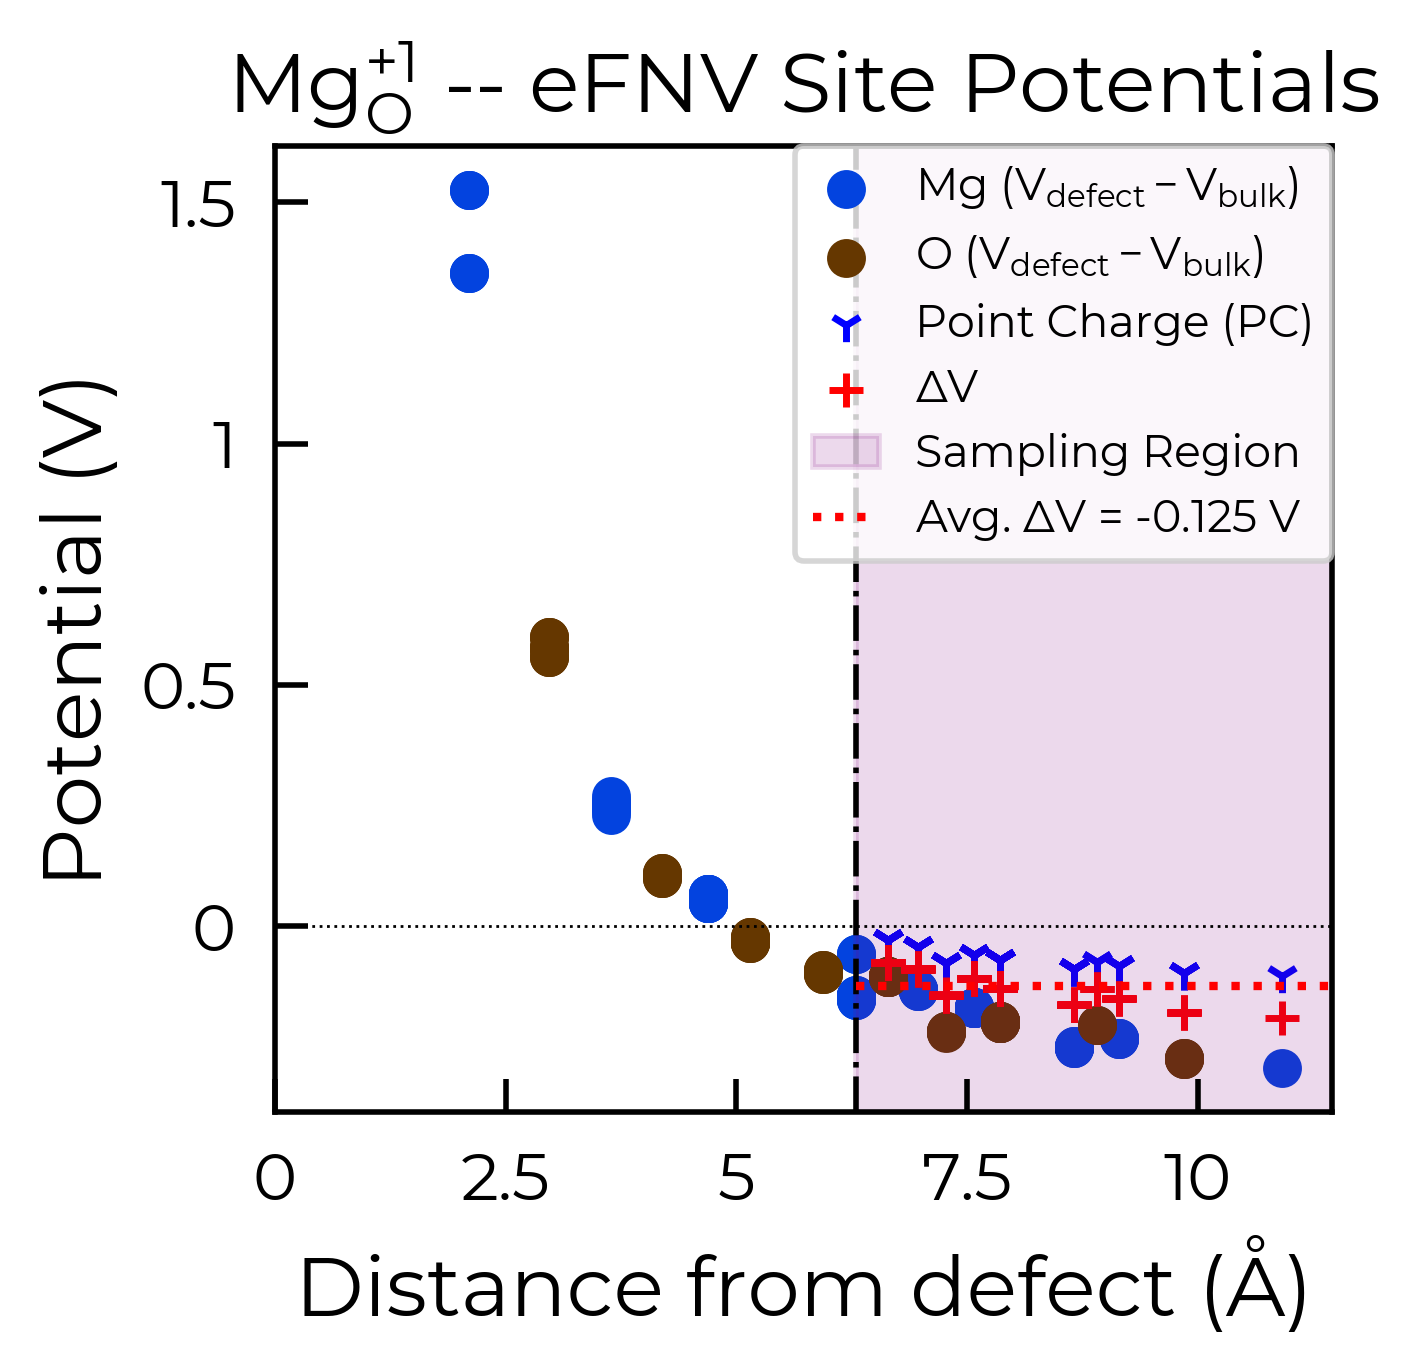

In [38]:
correction, plot = defect_entry_1_unperturbed.get_kumagai_correction(plot=True)


### Trying a new broadening value

In [39]:
##Since the existing code is not loading bulk/defect site potentials into the calculation metadata, this a temporary workaround

from doped.utils.parsing import RunParser
from pymatgen.io.common import VolumetricData


defect_cube = VolumetricData.from_cube("/examples/MgO_qe/Mg_O_+1_unperturbed/espresso_std/Mg_O_+1_unperturbed.cube")
bulk_cube = VolumetricData.from_cube("/Users/atharvaanturkar/PycharmProjects/doped_QE/examples/MgO_qe/MgO_bulk/espresso_std/MgO_bulk.cube")

defect_site_potentials_dict = RunParser('espresso').get_atomic_site_potentials(cube_file = defect_cube, beta = 2.7)
bulk_site_potentials_dict = RunParser('espresso').get_atomic_site_potentials(cube_file = bulk_cube, beta = 2.7)

defect_entry_1_unperturbed.calculation_metadata.update(
            {
                "bulk_site_potentials": bulk_site_potentials_dict['site_potentials'],
                "defect_site_potentials": defect_site_potentials_dict['site_potentials'],
            })



Calculated Kumagai (eFNV) correction is 0.283 eV


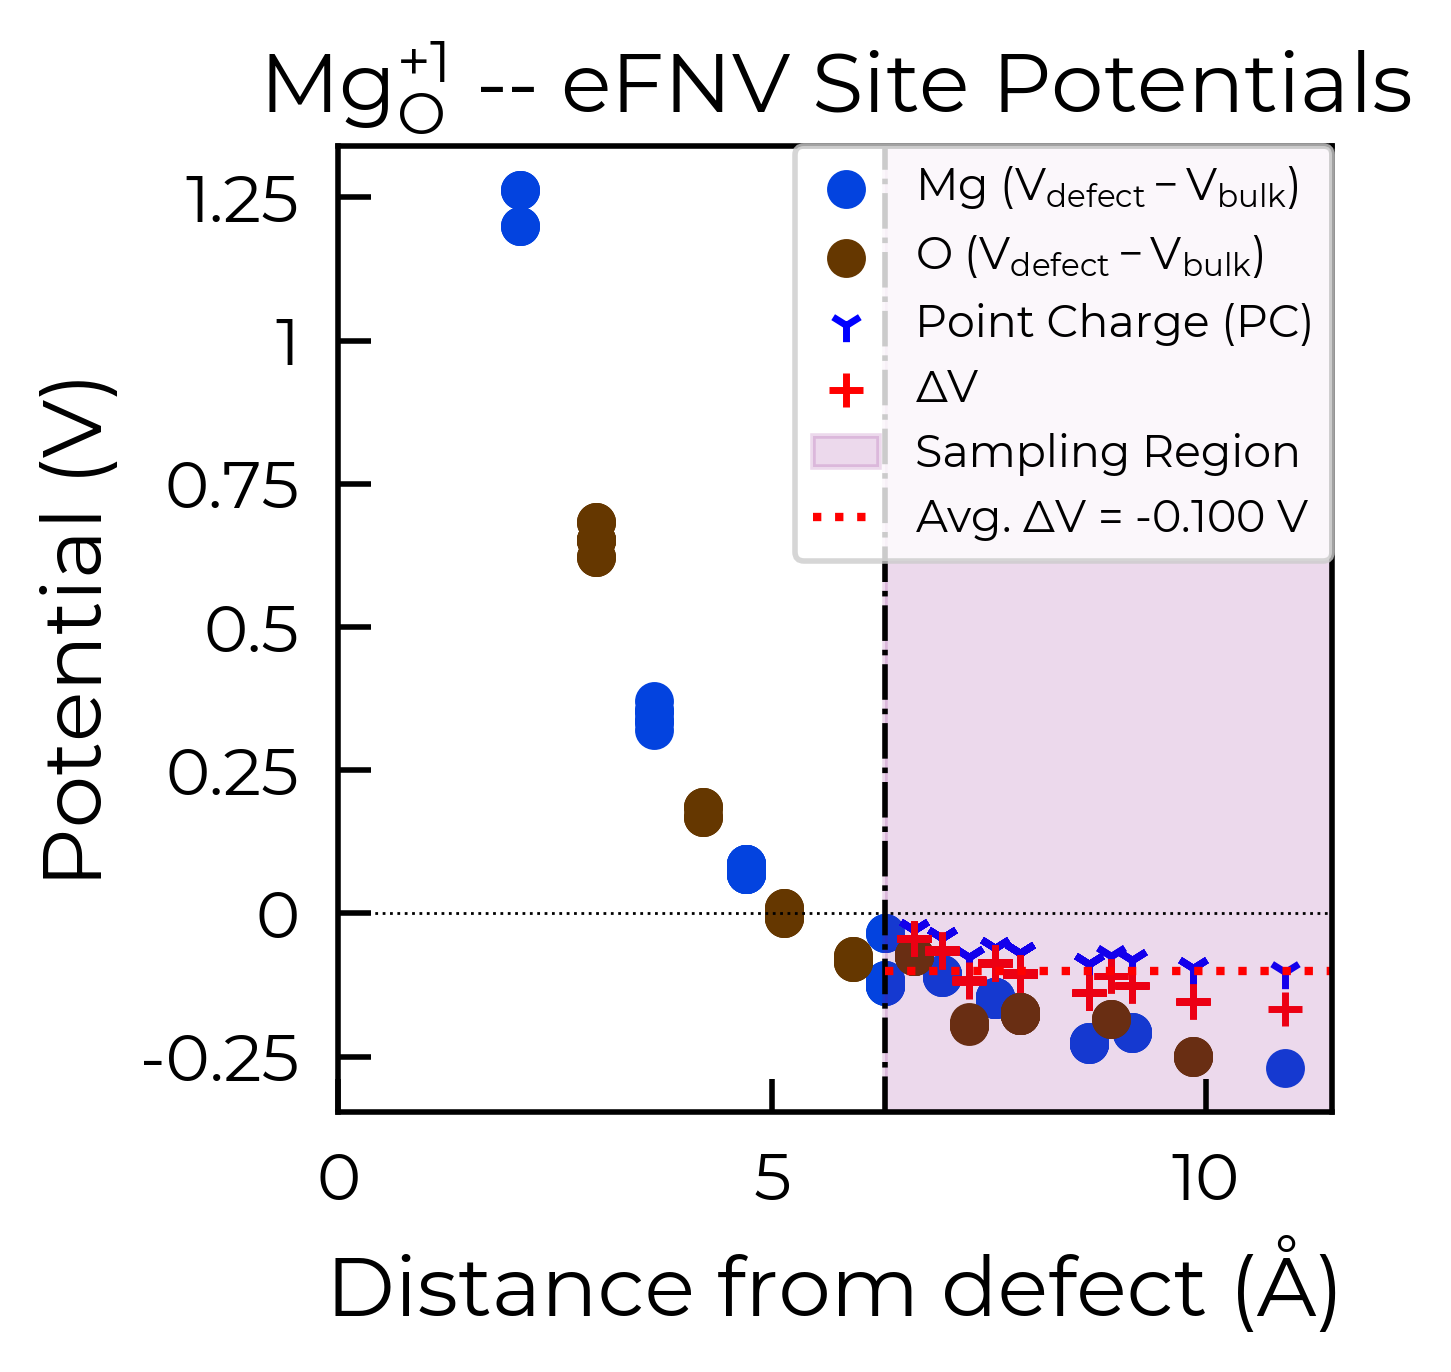

In [40]:
correction, plot = defect_entry_1_unperturbed.get_kumagai_correction(plot=True)


As seen above, a value of 2.7 gives a much better value for the kumagai correction. (Better in comparison to the vasp values calculated later)

## Perturbed Defects

Note: The DefectParserEspresso reads the charge from the defect files only (in its current state), therefore accurate naming of the folder is necessary at the moment, to run the perturbed and unperturbed defects through the parser, one case(perturbed/unperturbed) needs to be calculated under the file name Mg_O_+X and then needs to be changed for the other case in Mg_O_+X form and the defect parser should be re-run. (make sure to add the appropriate cube files to load them into the calculation metadata.)

In [52]:
defect_entry_1 = dp.defect_dict["Mg_O_+1"]

In [55]:
##Since the existing code is not loading bulk/defect site potentials into the calculation metadata, this a temporary workaround

from doped.utils.parsing import RunParser
from pymatgen.io.common import VolumetricData


defect_cube = VolumetricData.from_cube("/Users/atharvaanturkar/PycharmProjects/doped_QE/examples/MgO_qe/Mg_O_+1/espresso_std/Mg_O_+1.cube")
bulk_cube = VolumetricData.from_cube("/Users/atharvaanturkar/PycharmProjects/doped_QE/examples/MgO_qe/MgO_bulk/espresso_std/MgO_bulk.cube")

defect_site_potentials_dict = RunParser('espresso').get_atomic_site_potentials(cube_file = defect_cube, beta = 1.2)
bulk_site_potentials_dict = RunParser('espresso').get_atomic_site_potentials(cube_file = bulk_cube, beta = 1.2)

defect_entry_1.calculation_metadata.update(
            {
                "bulk_site_potentials": bulk_site_potentials_dict['site_potentials'],
                "defect_site_potentials": defect_site_potentials_dict['site_potentials'],
            })



Calculated Kumagai (eFNV) correction is 0.208 eV


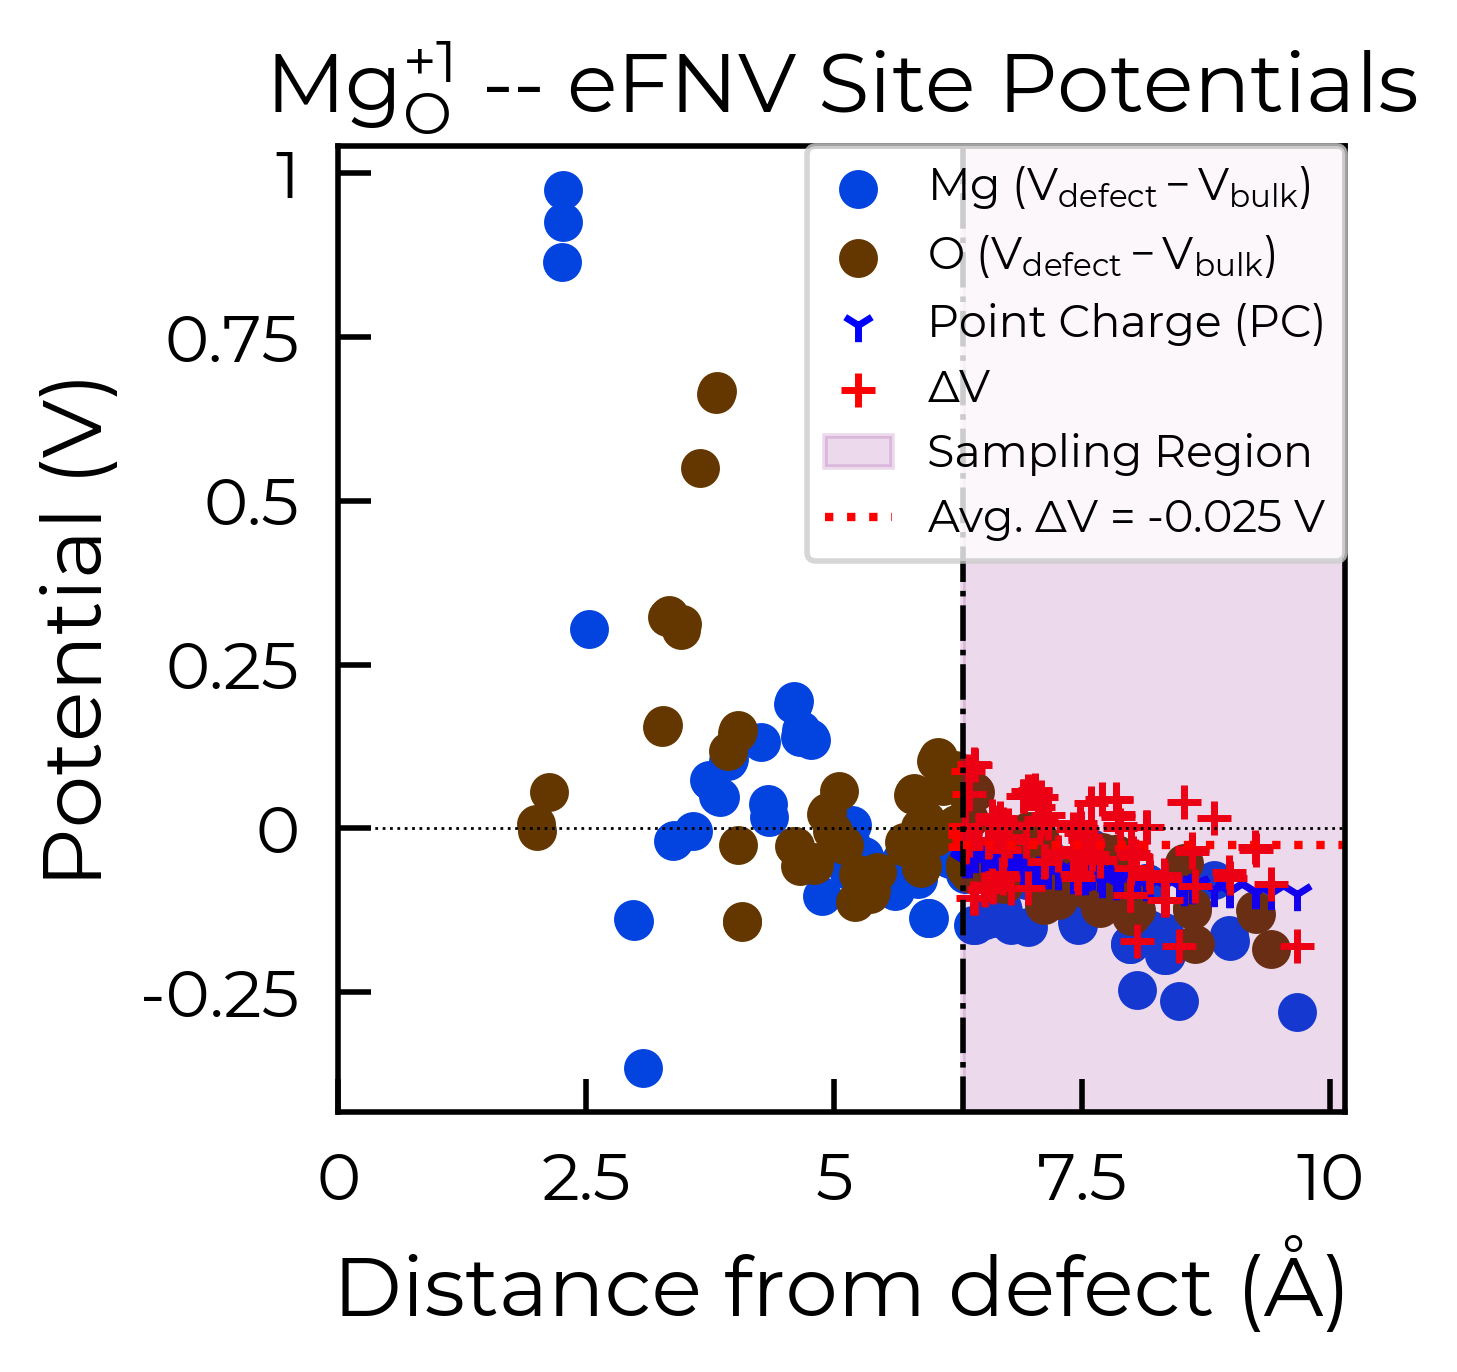

In [56]:
correction, plot = defect_entry_1.get_kumagai_correction(plot=True)


### Trying a new broadening value just like the unperturbed case

In [57]:
##Since the existing code is not loading bulk/defect site potentials into the calculation metadata, this a temporary workaround

from doped.utils.parsing import RunParser
from pymatgen.io.common import VolumetricData


defect_cube = VolumetricData.from_cube("/Users/atharvaanturkar/PycharmProjects/doped_QE/examples/MgO_qe/Mg_O_+1/espresso_std/Mg_O_+1.cube")
bulk_cube = VolumetricData.from_cube("/Users/atharvaanturkar/PycharmProjects/doped_QE/examples/MgO_qe/MgO_bulk/espresso_std/MgO_bulk.cube")

defect_site_potentials_dict = RunParser('espresso').get_atomic_site_potentials(cube_file = defect_cube, beta = 2.7)
bulk_site_potentials_dict = RunParser('espresso').get_atomic_site_potentials(cube_file = bulk_cube, beta = 2.7)

defect_entry_1.calculation_metadata.update(
            {
                "bulk_site_potentials": bulk_site_potentials_dict['site_potentials'],
                "defect_site_potentials": defect_site_potentials_dict['site_potentials'],
            })



Calculated Kumagai (eFNV) correction is 0.117 eV


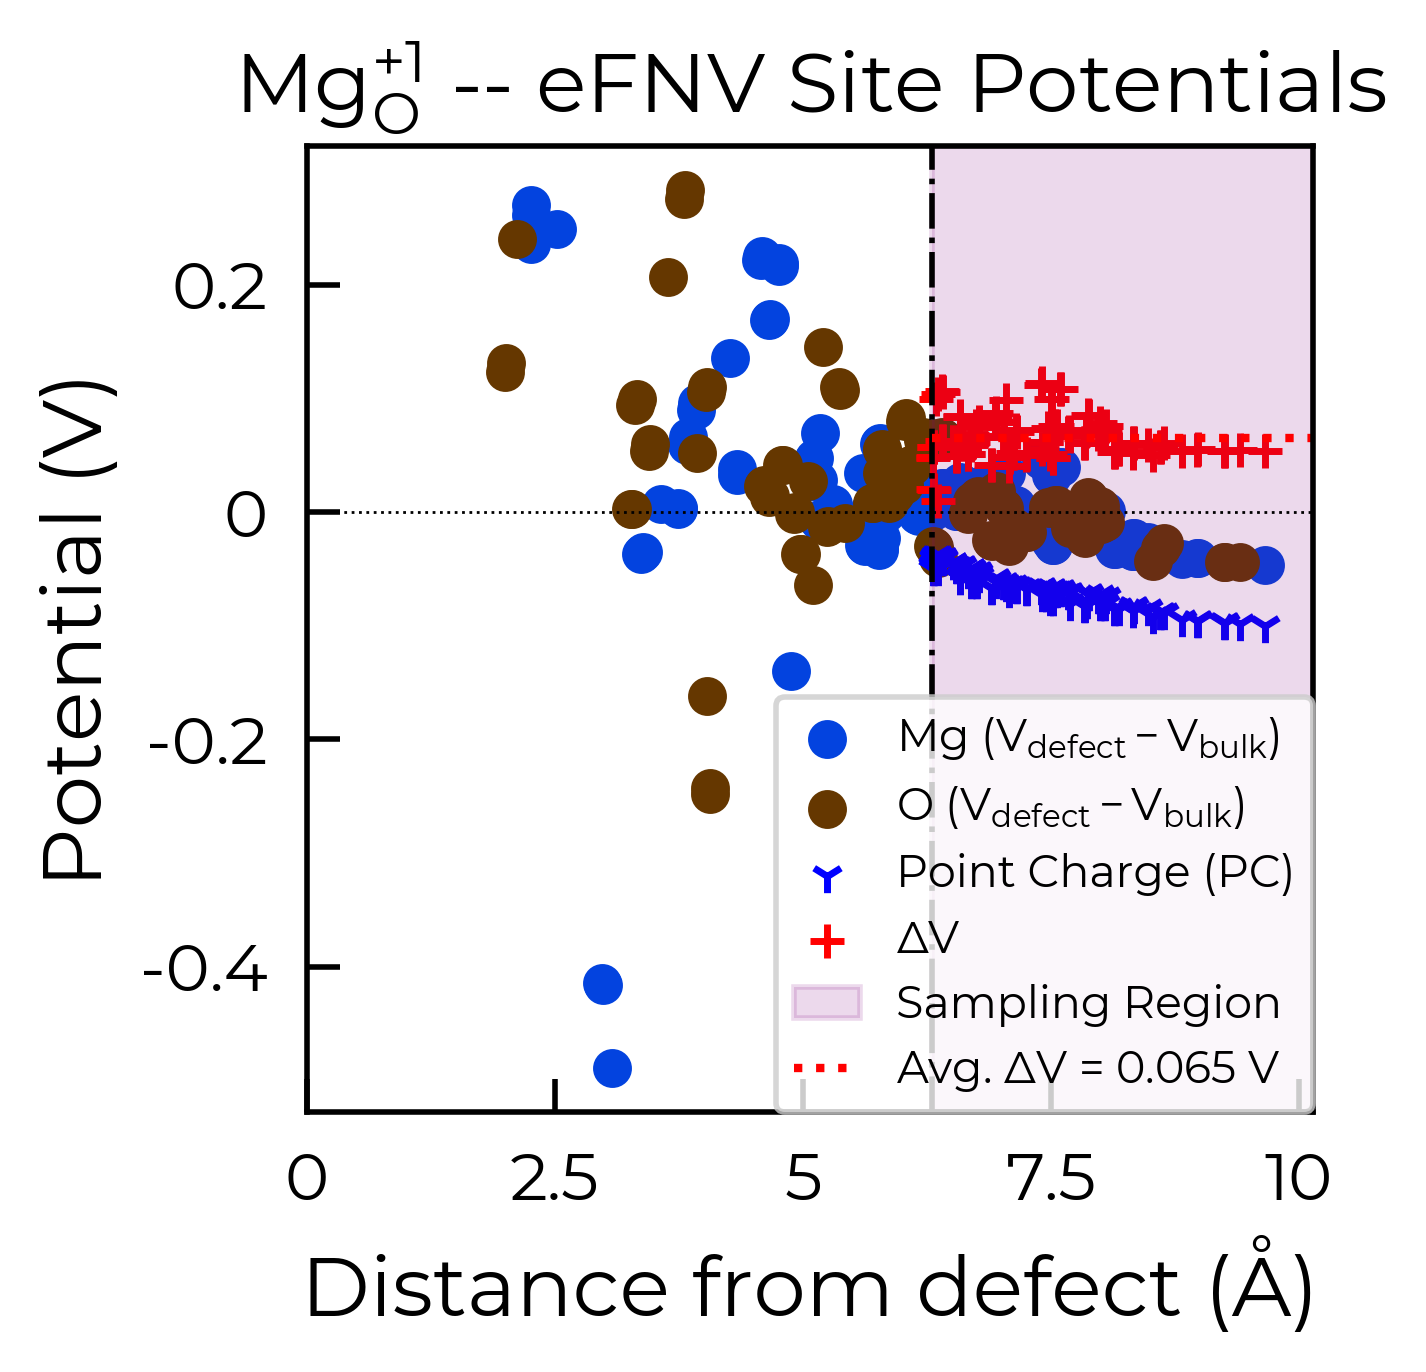

In [58]:
correction, plot = defect_entry_1.get_kumagai_correction(plot=True)


As seen above, a broadening value of 2.7 gives an incorrect value for the correction compared to 1.2 - this is opposite to the case of the unperturbed defect. (incorrectness/correctness of the values are decided by their match with VASP-doped calculations performed later in the notebook)

In [41]:
defect_entry_2 = dp.defect_dict["Mg_O_+2"]

In [42]:
##Since the existing code is not loading bulk/defect site potentials into the calculation metadata, this a temporary workaround

from doped.utils.parsing import RunParser
from pymatgen.io.common import VolumetricData


defect_cube = VolumetricData.from_cube("/Users/atharvaanturkar/PycharmProjects/doped_QE/examples/MgO_qe/Mg_O_+2/espresso_std/Mg_O_+2.cube")
bulk_cube = VolumetricData.from_cube("/Users/atharvaanturkar/PycharmProjects/doped_QE/examples/MgO_qe/MgO_bulk/espresso_std/MgO_bulk.cube")

defect_site_potentials_dict = RunParser('espresso').get_atomic_site_potentials(cube_file = defect_cube, beta = 1.2)
bulk_site_potentials_dict = RunParser('espresso').get_atomic_site_potentials(cube_file = bulk_cube, beta = 1.2)

defect_entry_2.calculation_metadata.update(
            {
                "bulk_site_potentials": bulk_site_potentials_dict['site_potentials'],
                "defect_site_potentials": defect_site_potentials_dict['site_potentials'],
            })



Calculated Kumagai (eFNV) correction is 0.713 eV


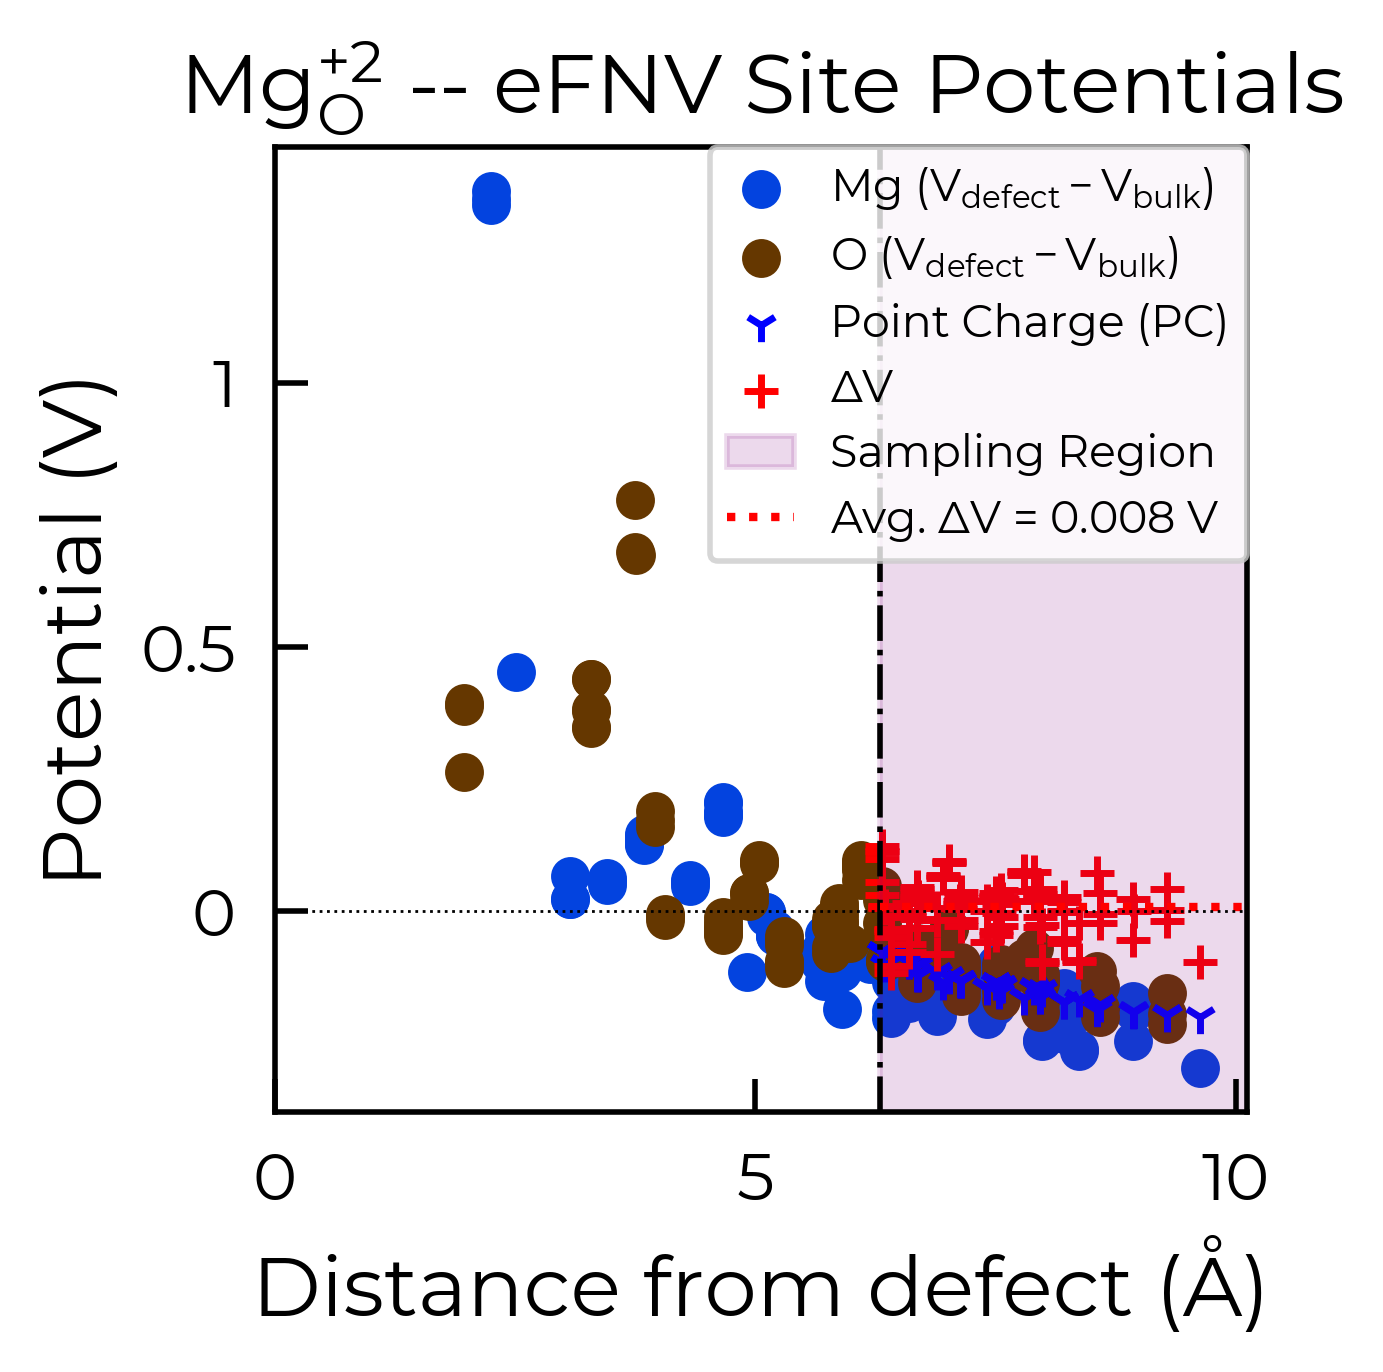

In [43]:
correction, plot = defect_entry_2.get_kumagai_correction(plot=True)


In [44]:
defect_entry_3 = dp.defect_dict["Mg_O_+3"]

In [45]:
##Since the existing code is not loading bulk/defect site potentials into the calculation metadata, this a temporary workaround

from doped.utils.parsing import RunParser
from pymatgen.io.common import VolumetricData


defect_cube = VolumetricData.from_cube("/Users/atharvaanturkar/PycharmProjects/doped_QE/examples/MgO_qe/Mg_O_+3/espresso_std/Mg_O_+3.cube")
bulk_cube = VolumetricData.from_cube("/Users/atharvaanturkar/PycharmProjects/doped_QE/examples/MgO_qe/MgO_bulk/espresso_std/MgO_bulk.cube")

defect_site_potentials_dict = RunParser('espresso').get_atomic_site_potentials(cube_file = defect_cube, beta =1.2)
bulk_site_potentials_dict = RunParser('espresso').get_atomic_site_potentials(cube_file = bulk_cube, beta = 1.2)

defect_entry_3.calculation_metadata.update(
            {
                "bulk_site_potentials": bulk_site_potentials_dict['site_potentials'],
                "defect_site_potentials": defect_site_potentials_dict['site_potentials'],
            })

Calculated Kumagai (eFNV) correction is 1.619 eV


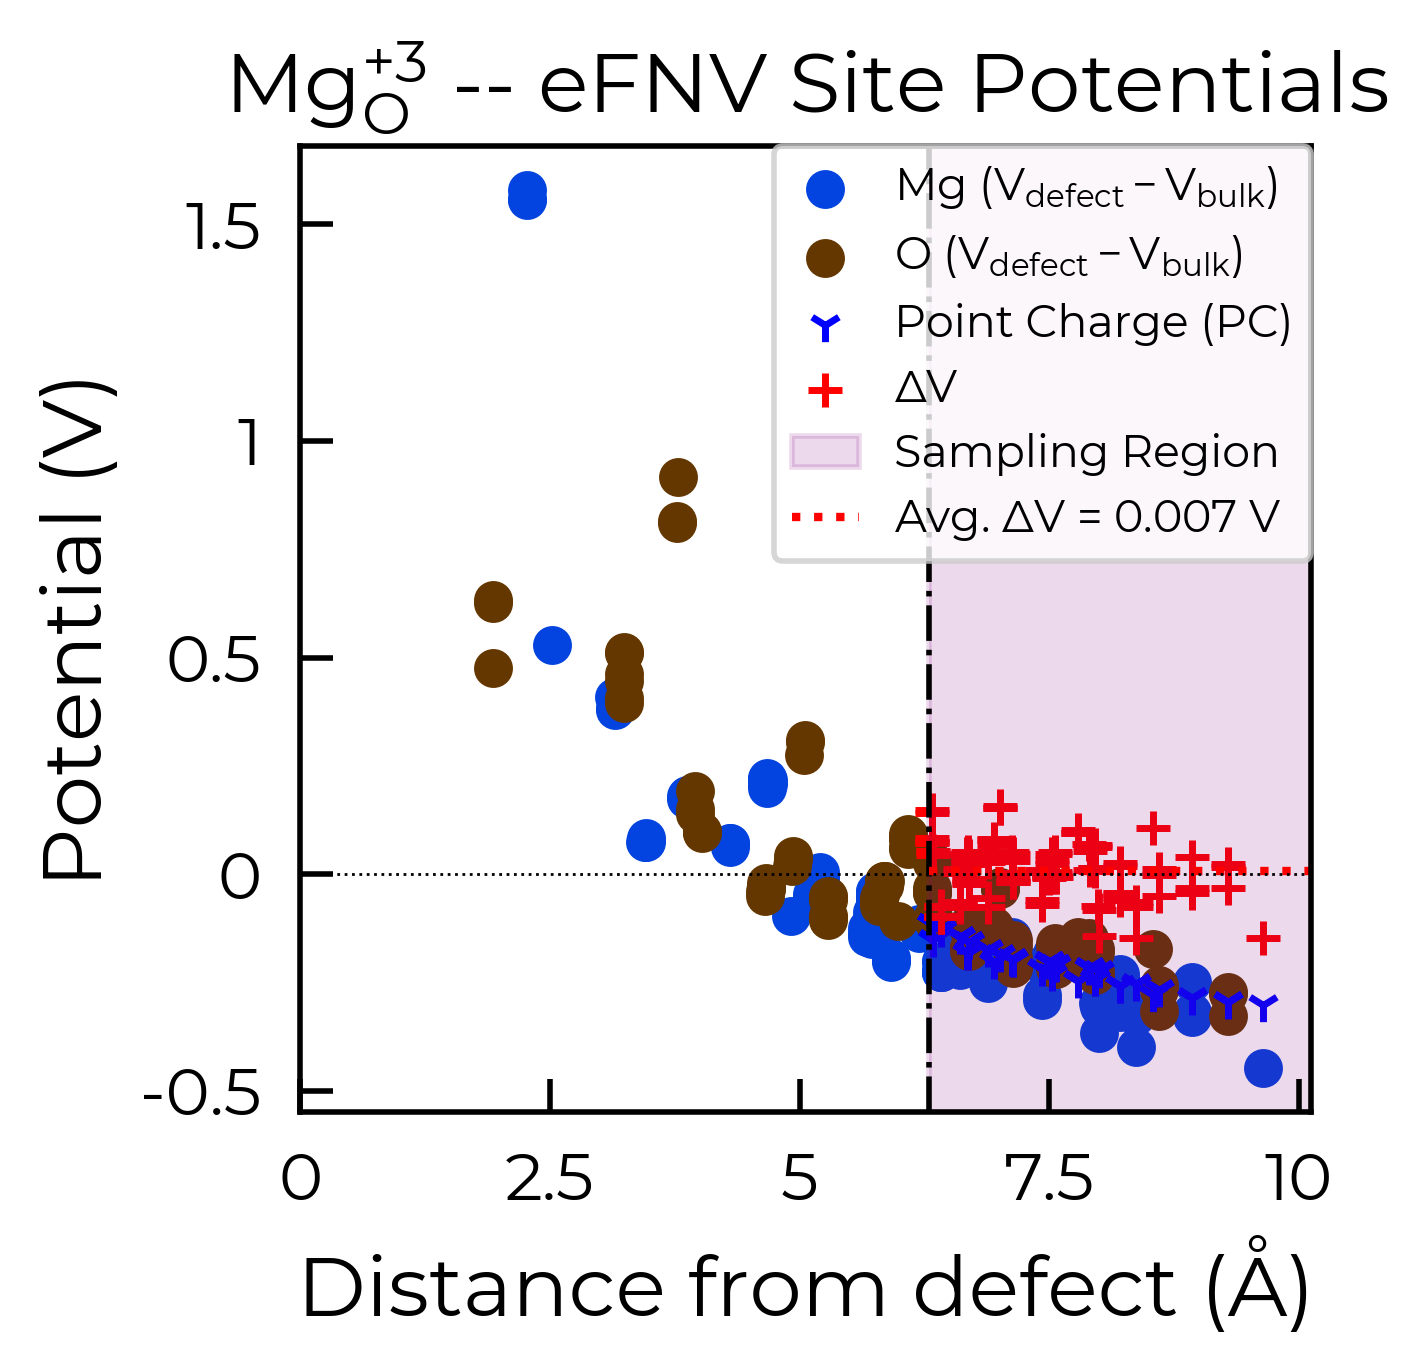

In [46]:
correction, plot = defect_entry_3.get_kumagai_correction(plot=True)


In [47]:
defect_entry_4 = dp.defect_dict["Mg_O_+4"]

In [48]:
##Since the existing code is not loading bulk/defect site potentials into the calculation metadata, this a temporary workaround

from doped.utils.parsing import RunParser
from pymatgen.io.common import VolumetricData


defect_cube = VolumetricData.from_cube("/Users/atharvaanturkar/PycharmProjects/doped_QE/examples/MgO_qe/Mg_O_+4/espresso_std/Mg_O_+4.cube")
bulk_cube = VolumetricData.from_cube("/Users/atharvaanturkar/PycharmProjects/doped_QE/examples/MgO_qe/MgO_bulk/espresso_std/MgO_bulk.cube")

defect_site_potentials_dict = RunParser('espresso').get_atomic_site_potentials(cube_file = defect_cube, beta =1.2)
bulk_site_potentials_dict = RunParser('espresso').get_atomic_site_potentials(cube_file = bulk_cube, beta = 1.2)

defect_entry_4.calculation_metadata.update(
            {
                "bulk_site_potentials": bulk_site_potentials_dict['site_potentials'],
                "defect_site_potentials": defect_site_potentials_dict['site_potentials'],
            })



Calculated Kumagai (eFNV) correction is 2.560 eV


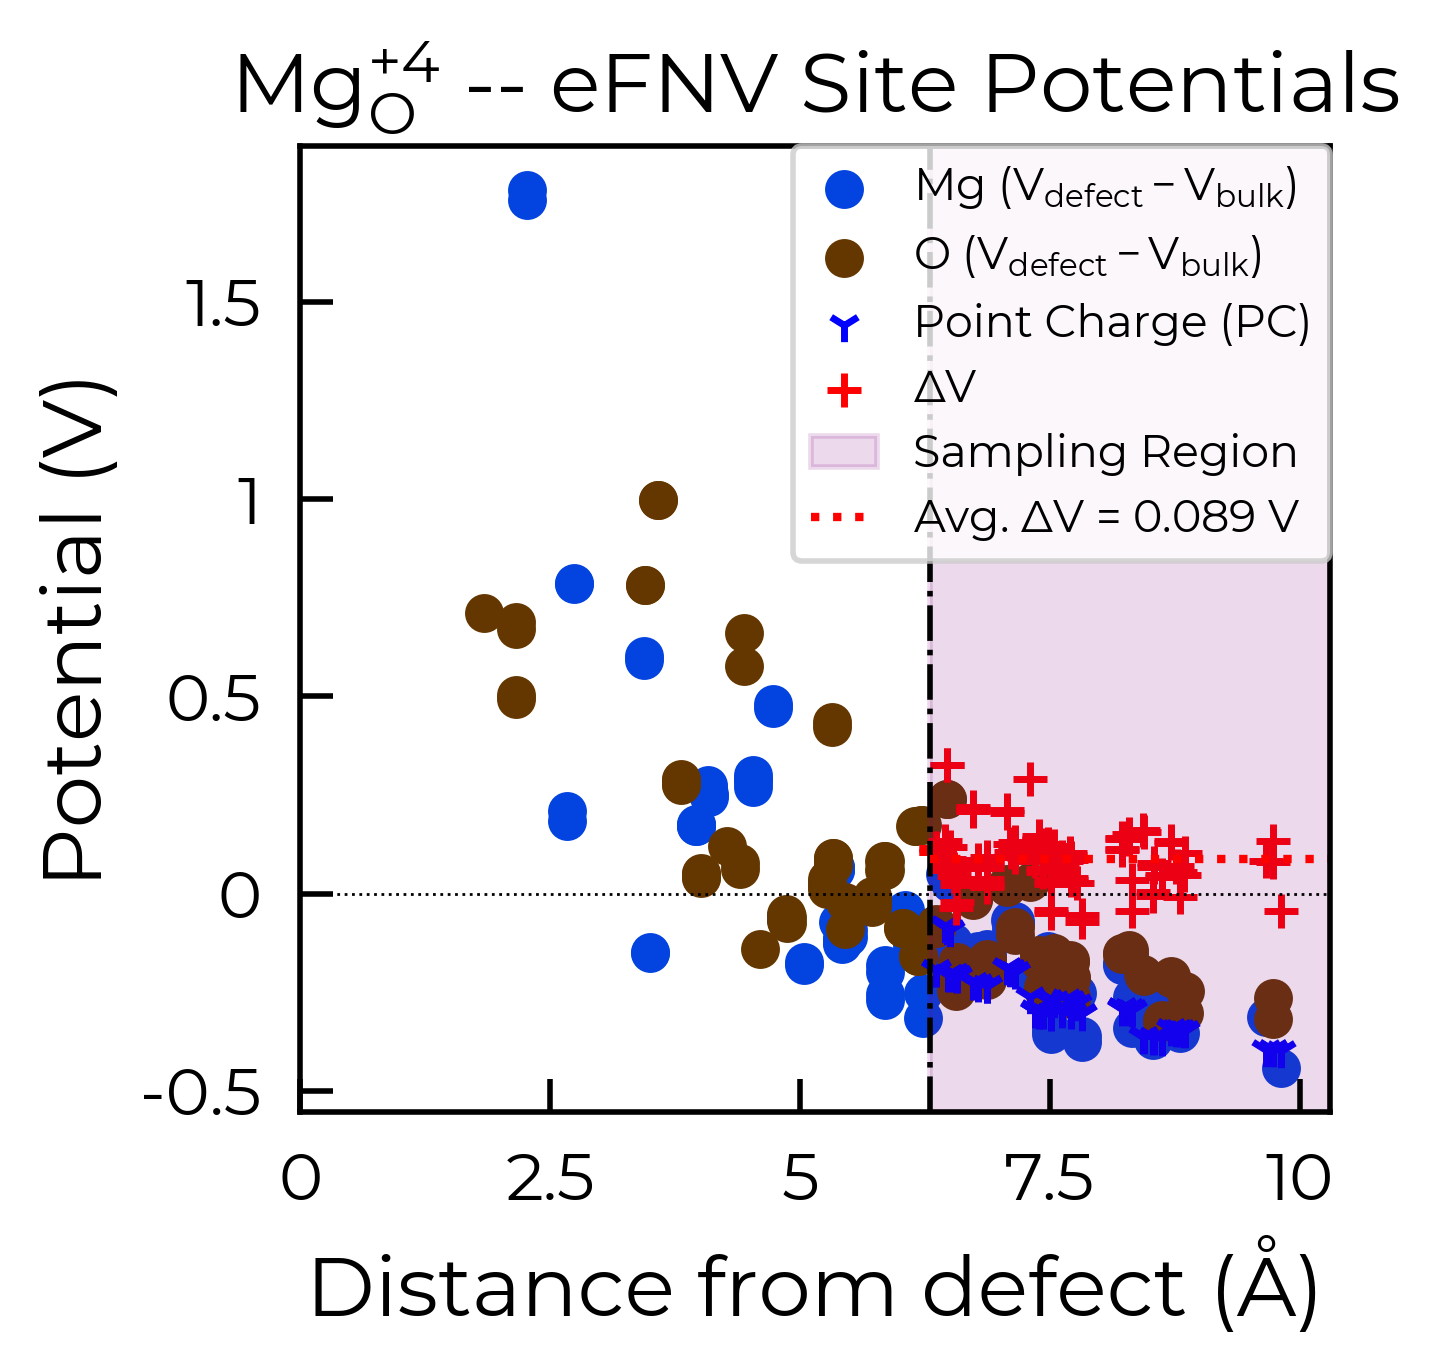

In [49]:
correction, plot = defect_entry_4.get_kumagai_correction(plot=True)


# VASP files

In [16]:
dp_vasp = DefectsParser(
   output_path="/Users/atharvaanturkar/PycharmProjects/doped_QE/examples/MgO/Defects/",  # directory containing the defect calculation folders
    dielectric=dielectric,  # dielectric needed for charge corrections
     #processes=1,  # Can set the number of processes to 1 if you're having issues with multiprocessing
code = 'vasp')

Parsing Mg_O_+1/vasp_std:   0%|          | 0/6 [00:08<?, ?it/s]                   

[WARN] Could not patch 'atomic_states': atomic_states is not a property on <class 'pymatgen.io.espresso.outputs.pwxml.PWxml'>.
[WARN] Could not patch 'kpoints_opt_props': kpoints_opt_props is not a property on <class 'pymatgen.io.espresso.outputs.pwxml.PWxml'>.
[WARN] Could not patch 'atomic_states': atomic_states is not a property on <class 'pymatgen.io.espresso.outputs.pwxml.PWxml'>.
[WARN] Could not patch 'kpoints_opt_props': kpoints_opt_props is not a property on <class 'pymatgen.io.espresso.outputs.pwxml.PWxml'>.
[WARN] Could not patch 'atomic_states': atomic_states is not a property on <class 'pymatgen.io.espresso.outputs.pwxml.PWxml'>.
[WARN] Could not patch 'kpoints_opt_props': kpoints_opt_props is not a property on <class 'pymatgen.io.espresso.outputs.pwxml.PWxml'>.
[WARN] Could not patch 'atomic_states': atomic_states is not a property on <class 'pymatgen.io.espresso.outputs.pwxml.PWxml'>.
[WARN] Could not patch 'kpoints_opt_props': kpoints_opt_props is not a property on <cla

Parsed Mg_O_+1_unperturbed/vasp_std: 100%|██████████| 6/6 [01:09<00:00, 11.50s/it]


In [17]:
defect_entry_vasp_1_unperturbed = dp_vasp.defect_dict["Mg_O_+1_unperturbed_+1"]

Calculated Kumagai (eFNV) correction is 0.274 eV


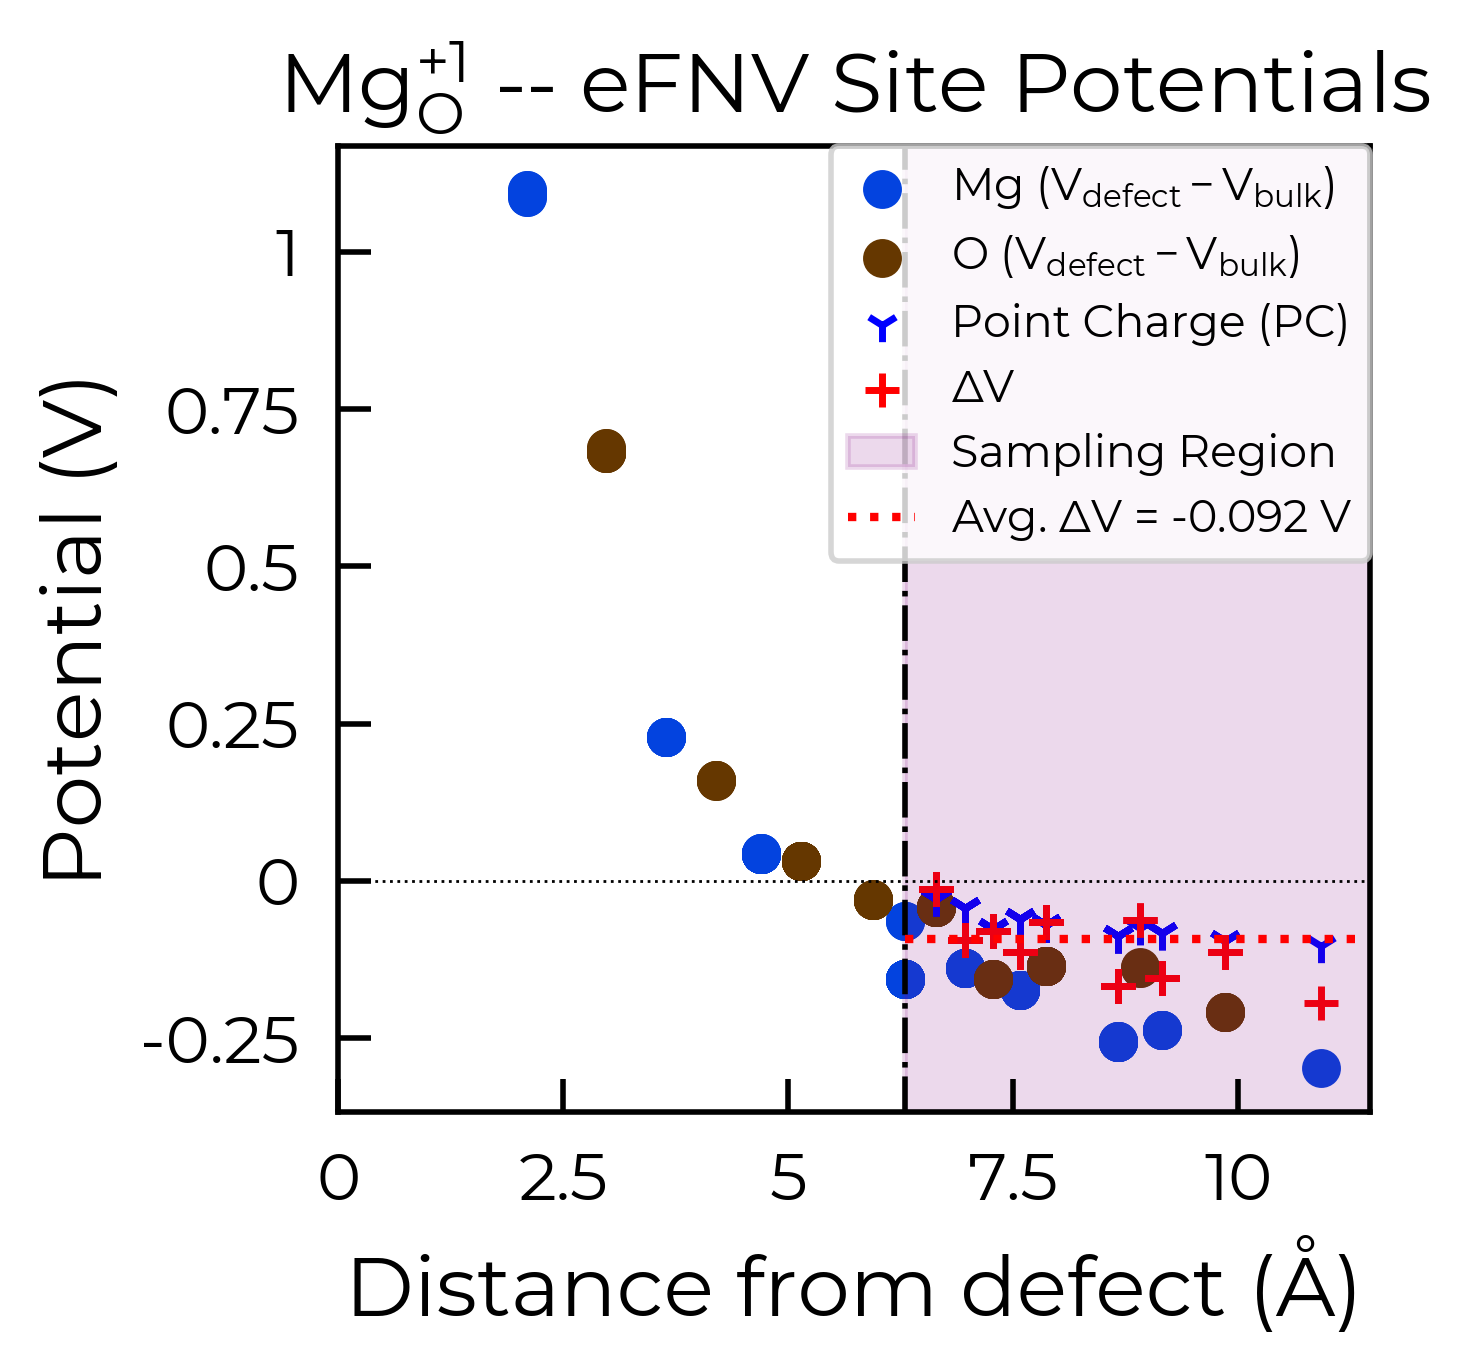

In [18]:
correction, plot = defect_entry_vasp_1_unperturbed.get_kumagai_correction(plot=True)


In [59]:
defect_entry_vasp_1 = dp_vasp.defect_dict["Mg_O_+1"]

Calculated Kumagai (eFNV) correction is 0.199 eV


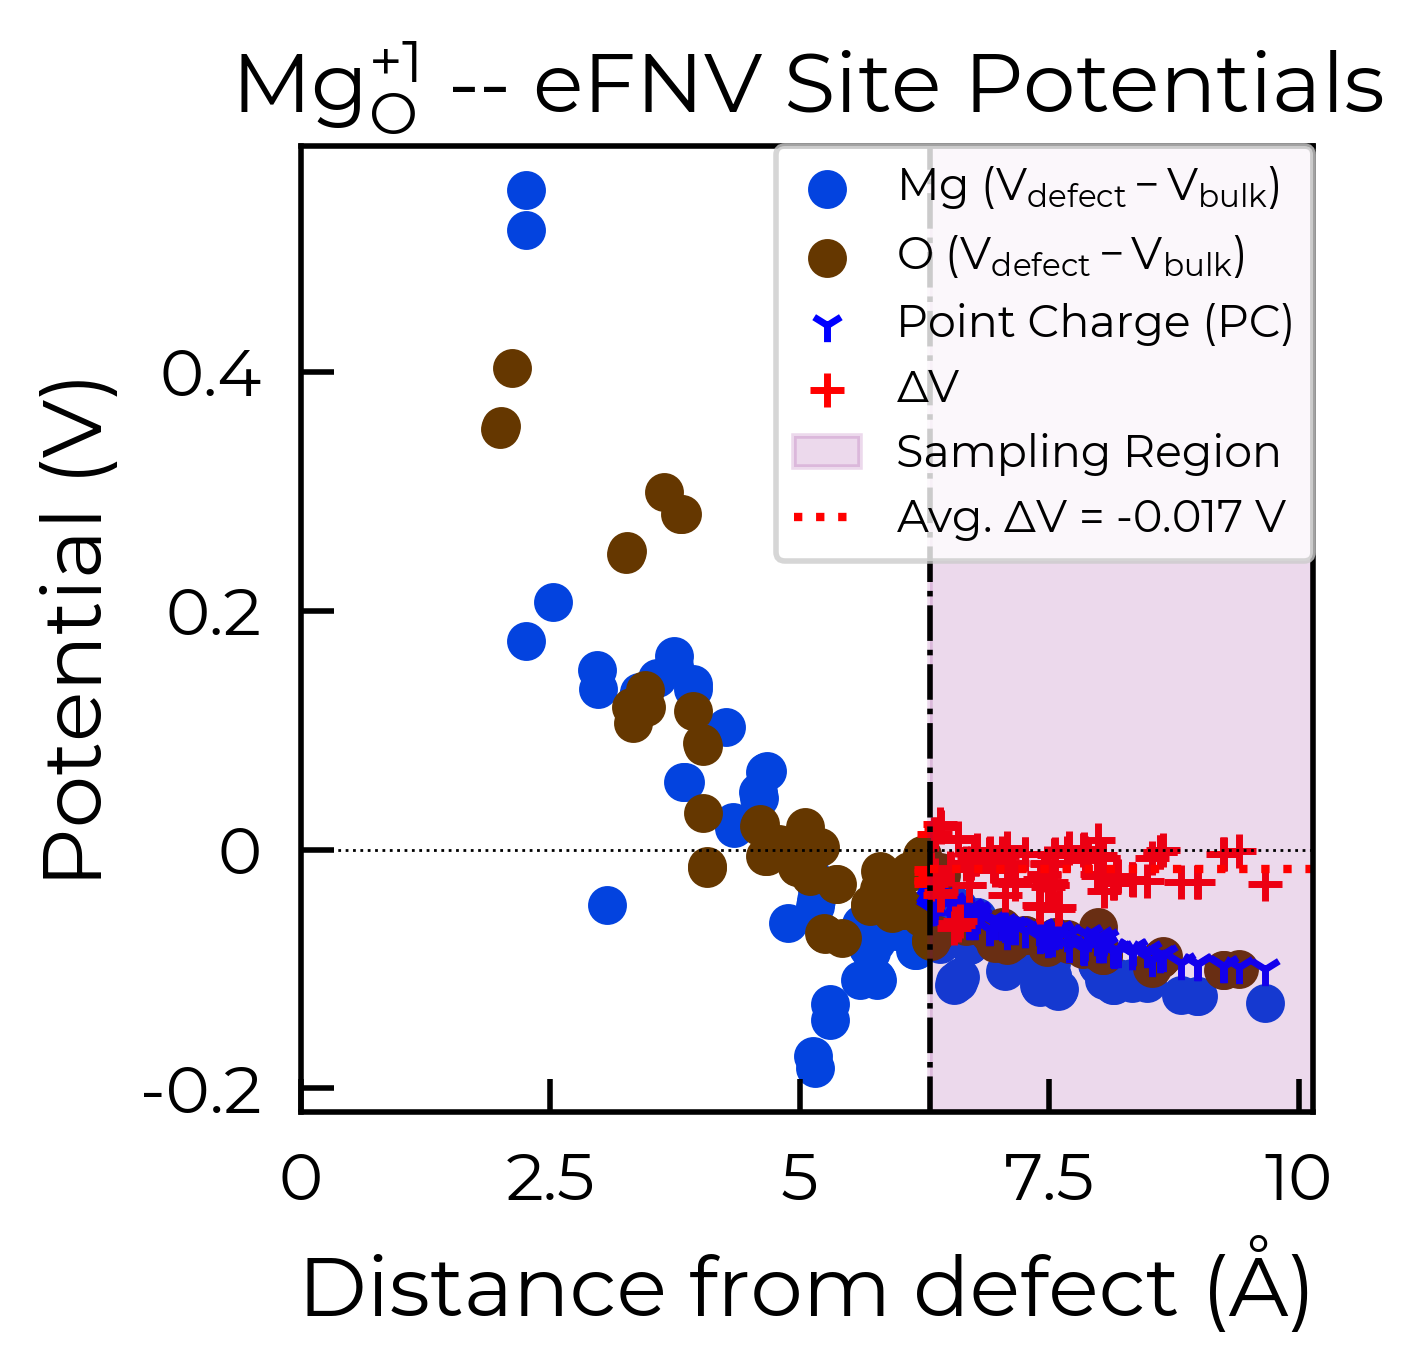

In [60]:
correction, plot = defect_entry_vasp_1.get_kumagai_correction(plot=True)


In [21]:
defect_entry_vasp_2 = dp_vasp.defect_dict["Mg_O_+2"]

Calculated Kumagai (eFNV) correction is 0.723 eV


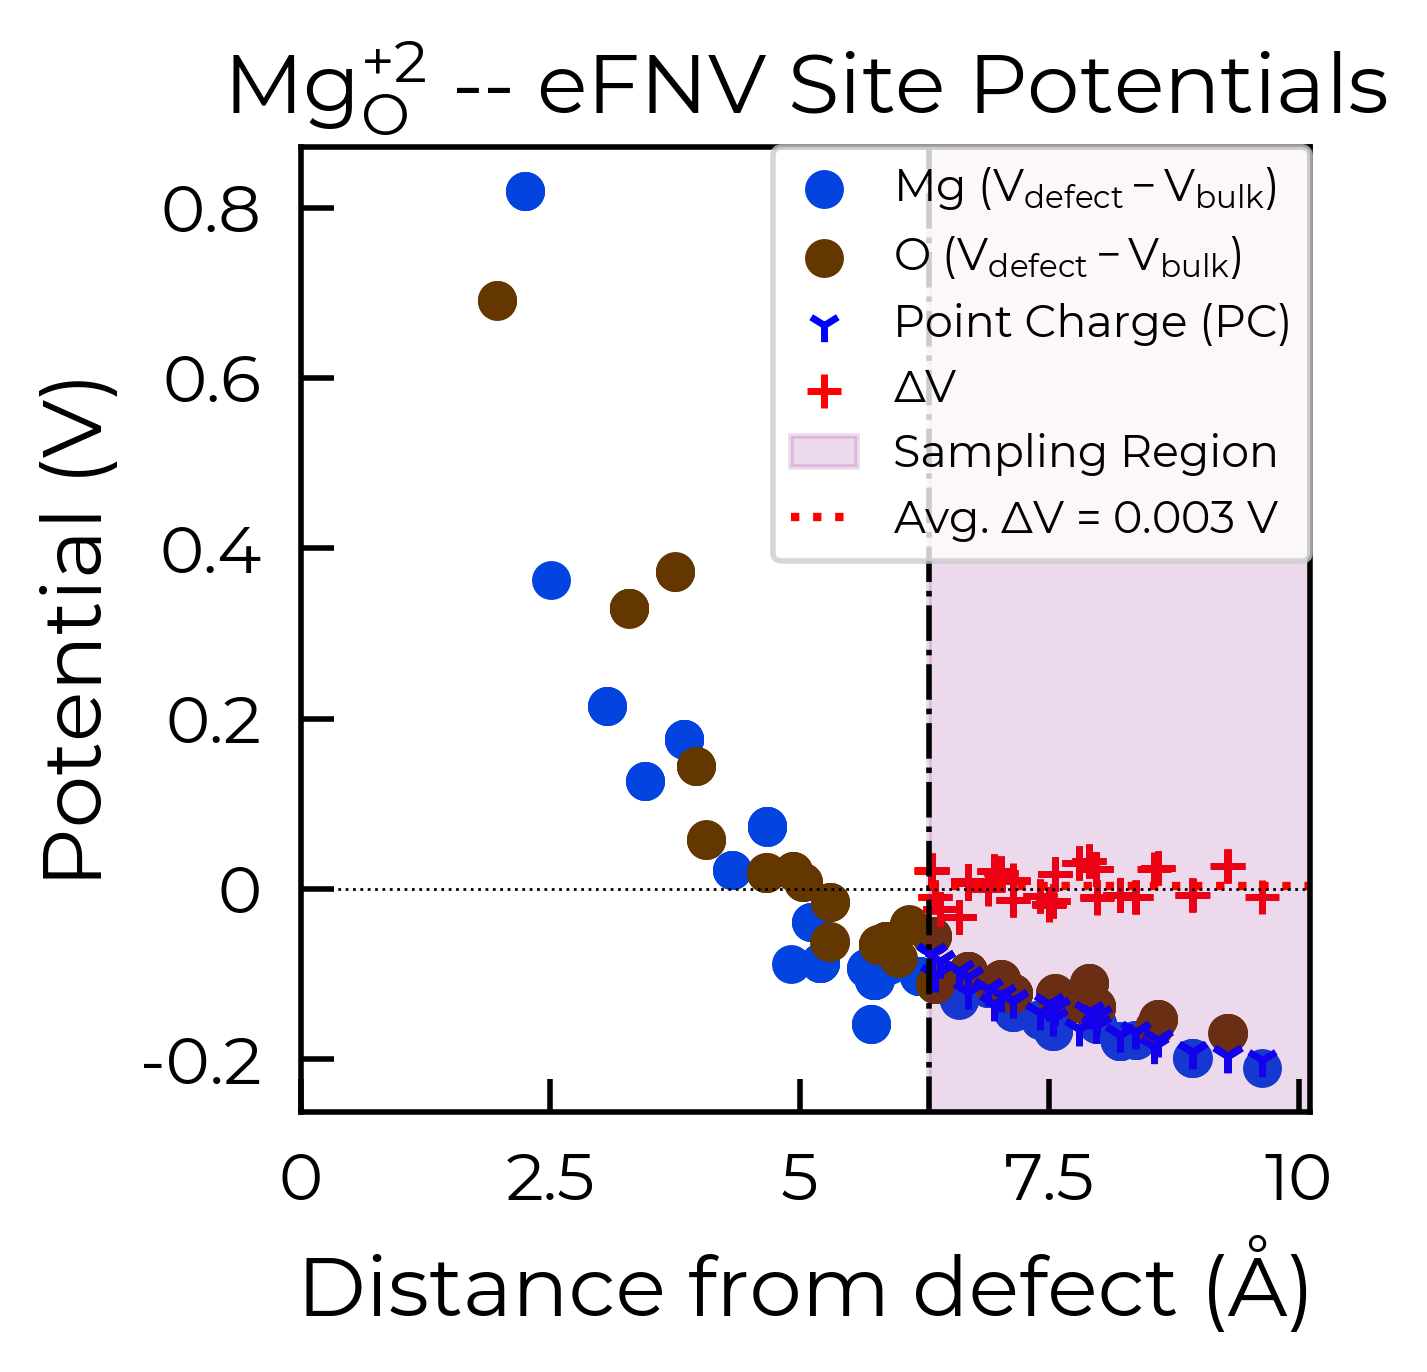

In [22]:
correction, plot = defect_entry_vasp_2.get_kumagai_correction(plot=True)


In [23]:
defect_entry_vasp_3 = dp_vasp.defect_dict["Mg_O_+3"]

Calculated Kumagai (eFNV) correction is 1.572 eV


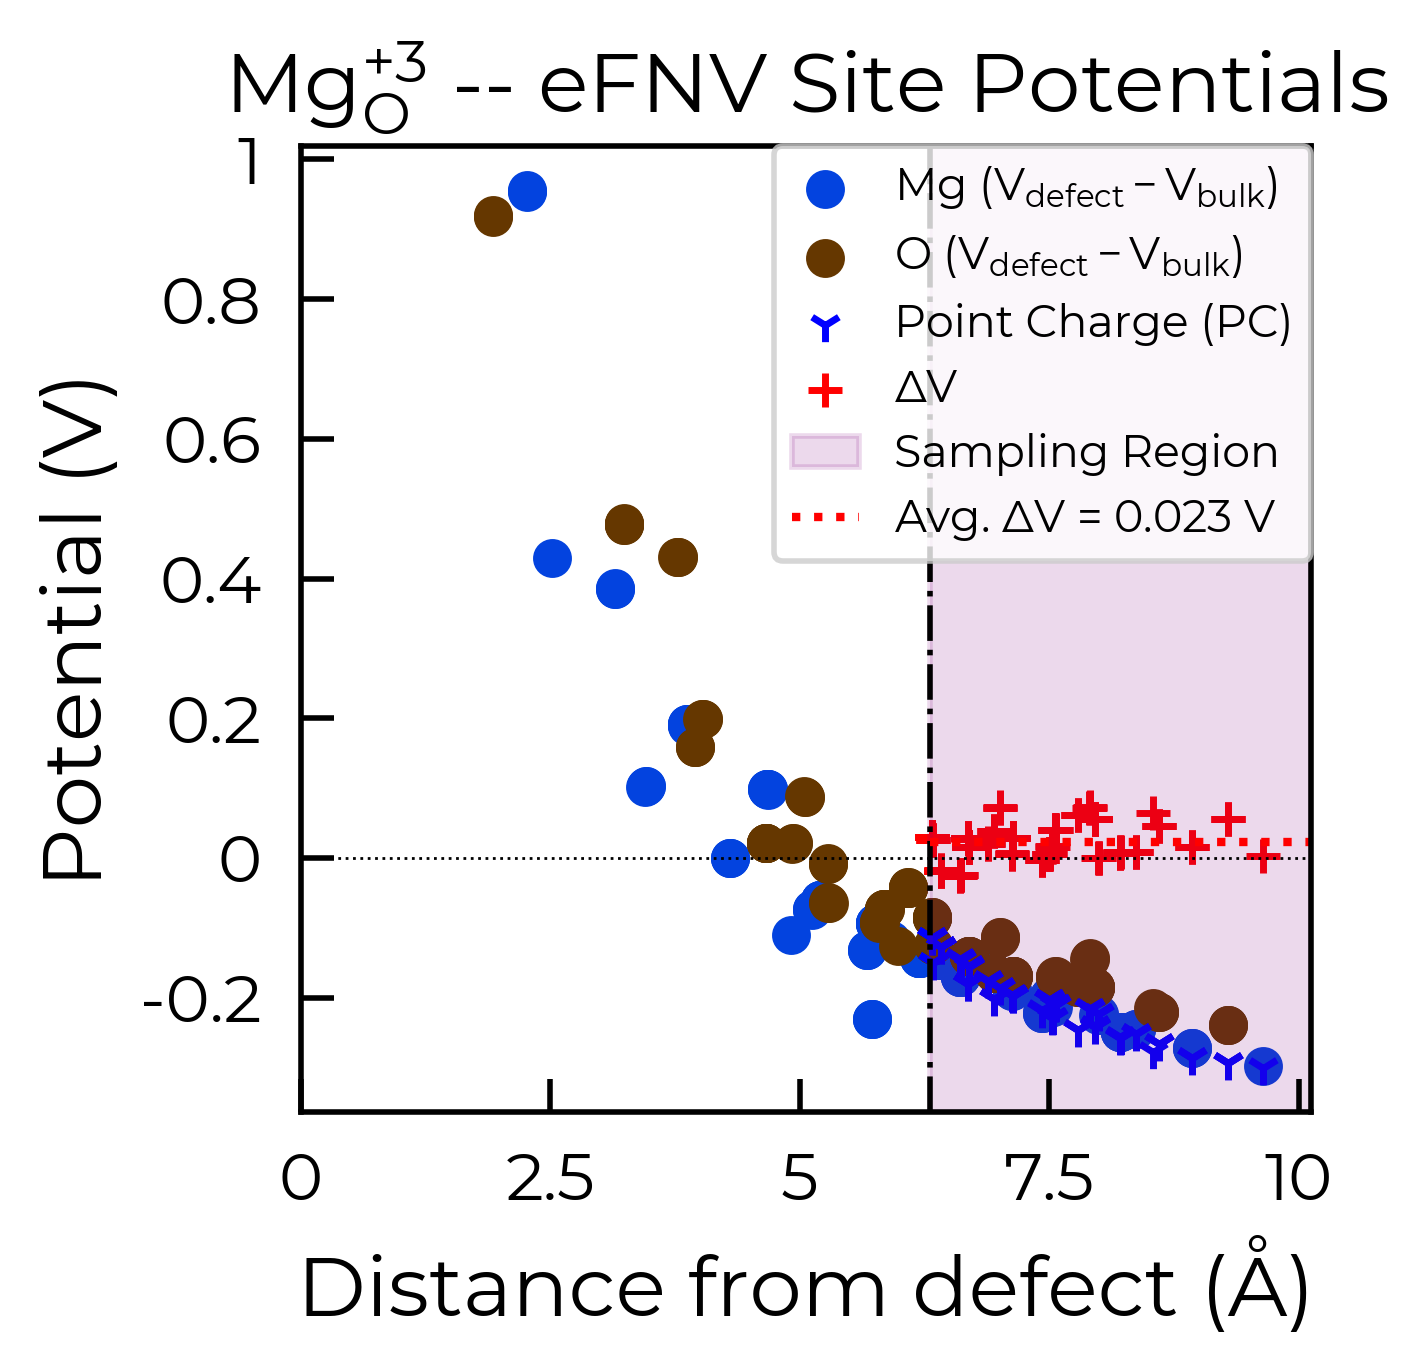

In [24]:
correction, plot = defect_entry_vasp_3.get_kumagai_correction(plot=True)


In [25]:
defect_entry_vasp_4 = dp_vasp.defect_dict["Mg_O_+4"]

Calculated Kumagai (eFNV) correction is 2.586 eV


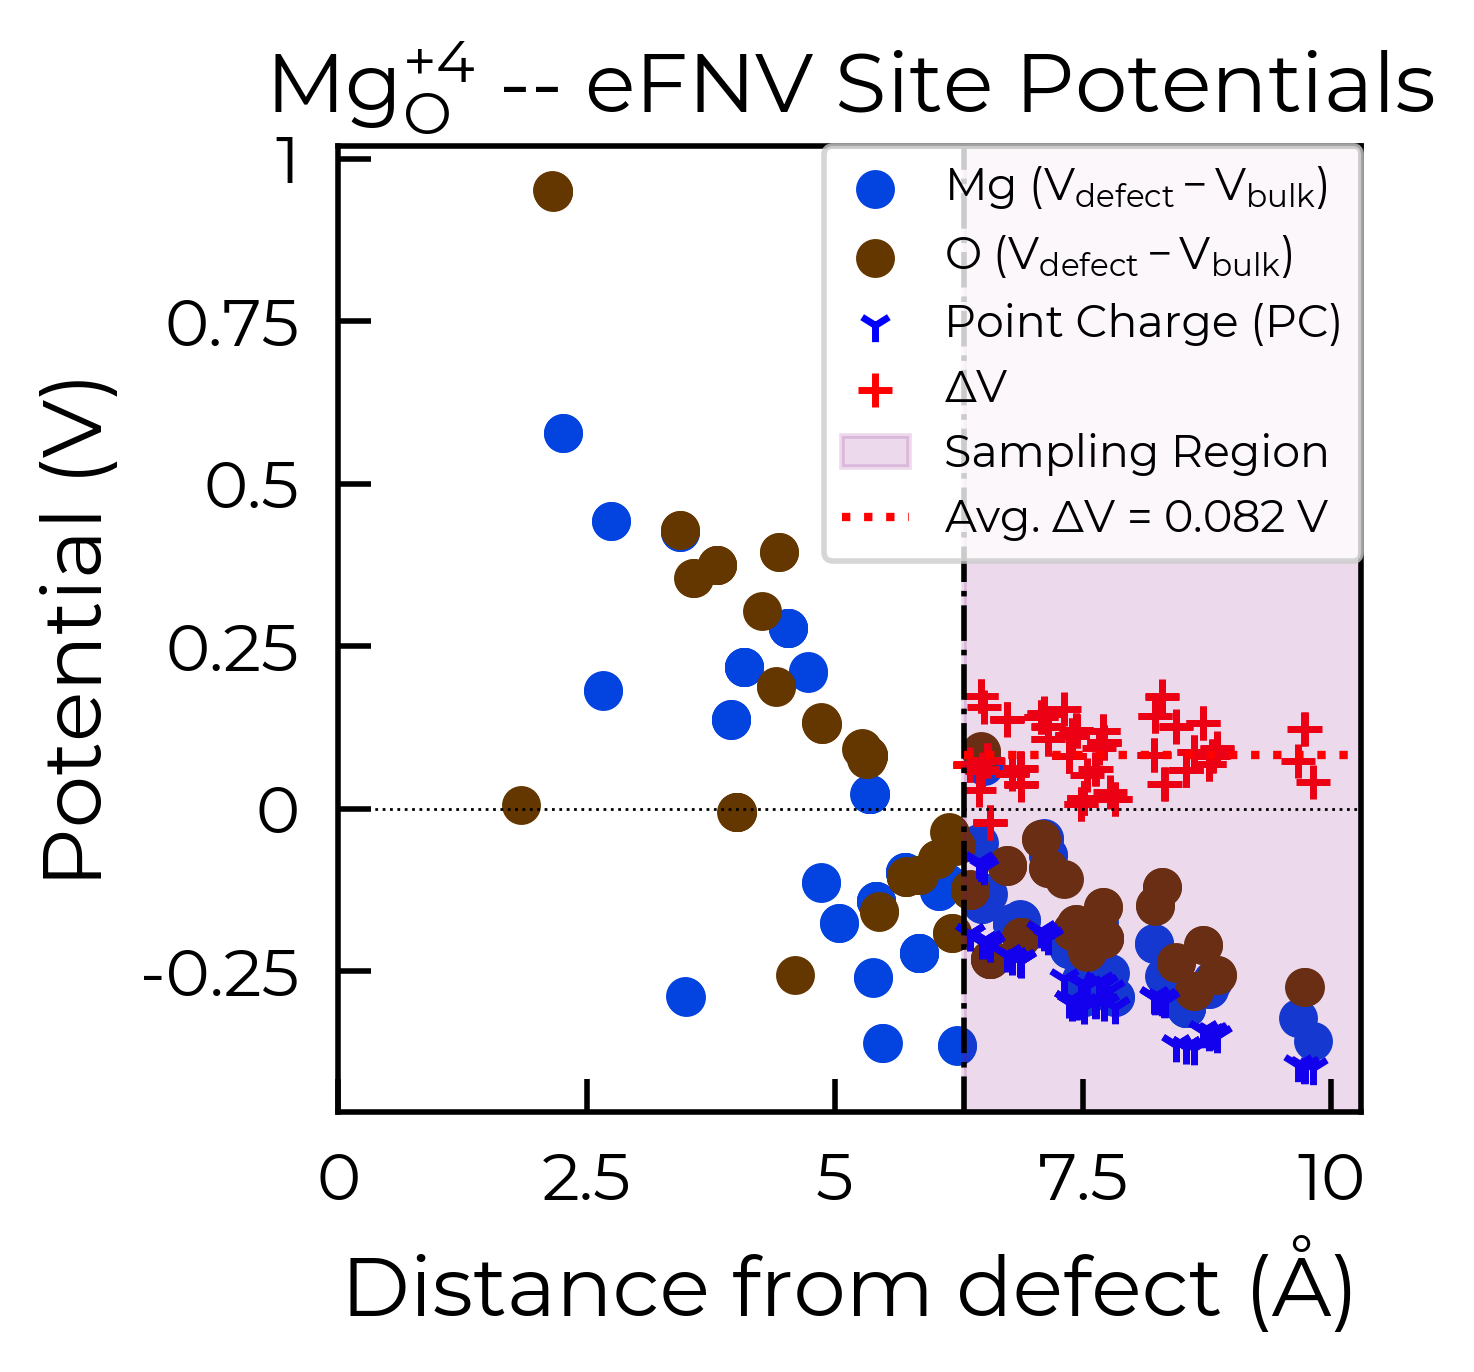

In [26]:
correction, plot = defect_entry_vasp_4.get_kumagai_correction(plot=True)

# Conclusions
1. The broadening factor seems to be dependent on the charge(to some extent) and majorly, the relaxed/unrelaxed state.
2. I can't determine a physical meaning of the broadening factor.